In [103]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tqdm.auto as tqdm
import pandas as pd
import random

# from models.dnn import DNN
# from models.cnn import CNN
# from models.resnet import ResNet

In [104]:
!nvidia-smi

Fri Oct 10 00:44:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             29W /   70W |    1238MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [105]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [106]:
curr_time = time.strftime("%Y%m%d")

In [107]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [108]:
train_batch_size = 512
test_batch_size = 64

In [109]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
test_size = len(test_dataset)

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=test_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

print(f'Train set size: {len(train_dataset)}')
print(f'Validation set size: {len(val_dataset)}')
print(f'Test set size: {len(test_dataset)}')

Train set size: 48000
Validation set size: 12000
Test set size: 10000


# Define Model (this section is for colab)

In [110]:
class DNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_layers: list = [256, 128],
        output_dim: int = 10,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        """
        Args:
            input_dim: number of input features (for MNIST, 28*28=784)
            hidden_layers: list of hidden layer sizes, e.g. [256, 128]
            output_dim: number of output features (for MNIST, 10 classes)
            dropout: dropout rate (0.0 means no dropout)
            batch_norm: whether to use batch normalization
            activation: activation function
        """
        super(DNN, self).__init__()
        self.activation = self._activation(activation)

        layers = []

        prev_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten input image
        return self.model(x)

    def _activation(self, act_str):
        if act_str == 'relu':
            return nn.ReLU()
        elif act_str == 'tanh':
            return nn.Tanh()
        elif act_str == 'sigmoid':
            return nn.Sigmoid()
        elif act_str == 'leaky_relu':
            return nn.LeakyReLU()
        elif act_str == 'softmax':
            return nn.Softmax(dim=1)
        elif act_str == 'gelu':
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation function: {act_str}")

class CNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        input_channels: int = 1,
        conv_layers: list = [32, 64],
        fc_layers: list = [128],
        output_dim: int = 10,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        """
        Args:
            input_dim: number of input features (for MNIST, 28*28=784)
            input_channels: number of input channels (for MNIST, 1 channel)
            conv_layers: list of convolutional layers
            fc_layers: list of fully connected layer sizes after feature extraction
            output_dim: number of output features (for MNIST, 10 classes)
            kernel_size: size of the convolutional kernel, e.g. 3x3
            stride: stride of the convolution
            padding: padding for the convolution
            dropout: dropout rate (0.0 means no dropout)
            batch_norm: whether to use batch normalization
            activation: activation function
        """
        super(CNN, self).__init__()
        self.activation = self._activation(activation)

        # Convolutional layers
        conv_blocks = []
        prev_channels = input_channels
        for out_channels in conv_layers:
            conv_blocks.append(nn.Conv2d(prev_channels, out_channels, kernel_size, stride, padding))
            if batch_norm:
                conv_blocks.append(nn.BatchNorm2d(out_channels))
            conv_blocks.append(self.activation)
            conv_blocks.append(nn.MaxPool2d(2, 2))
            if dropout > 0:
                conv_blocks.append(nn.Dropout2d(dropout))
            prev_channels = out_channels

        self.feature_extractor = nn.Sequential(*conv_blocks)

        # Compute the immediate output size after conv layers
        img_size = int(input_dim ** 0.5)
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, img_size, img_size)
            conv_output = self.feature_extractor(dummy_input)
            conv_output_size = conv_output.view(1, -1).size(1)

        # Fully connected layers
        fc_layers = [conv_output_size] + fc_layers + [output_dim]
        fc_blocks = []
        for i in range(len(fc_layers) - 2):
            fc_blocks.append(nn.Linear(fc_layers[i], fc_layers[i+1]))
            if batch_norm:
                fc_blocks.append(nn.BatchNorm1d(fc_layers[i+1]))
            fc_blocks.append(self.activation)
            if dropout > 0:
                fc_blocks.append(nn.Dropout(dropout))
        # Final output layer
        fc_blocks.append(nn.Linear(fc_layers[-2], fc_layers[-1]))

        self.fc = nn.Sequential(*fc_blocks)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

    def _activation(self, act_str):
        if act_str == 'relu':
            return nn.ReLU()
        elif act_str == 'tanh':
            return nn.Tanh()
        elif act_str == 'sigmoid':
            return nn.Sigmoid()
        elif act_str == 'leaky_relu':
            return nn.LeakyReLU()
        elif act_str == 'softmax':
            return nn.Softmax(dim=1)
        elif act_str == 'gelu':
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation function: {act_str}")

class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
    ):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.downsample = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                # Force the feature maps to have the same shape
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        self.conv_layers = nn.Sequential(
            self.conv1,
            self.bn1,
            self.relu,
            self.conv2,
            self.bn2
        )

    def forward(self, x):
        out = self.conv_layers(x)
        out += self.downsample(x)  # Residual connection
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(
        self,
        input_channels: int = 1,
        n_blocks: list = [2, 2, 2, 2],
        output_dim: int = 10,
    ):
        """
        Args:
            input_channels: number of input channels (for MNIST, 1 channel)
            n_blocks: list with number of residual blocks in each layer
            output_dim: number of output features (for MNIST, 10 classes)
        """
        super(ResNet, self).__init__()

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Follow ResNet18 architecture
        self.layer1 = self._make_layer(64, 64, n_blocks[0])
        self.layer2 = self._make_layer(64, 128, n_blocks[1], stride=2)
        self.layer3 = self._make_layer(128, 256, n_blocks[2], stride=2)
        self.layer4 = self._make_layer(256, 512, n_blocks[3], stride=2)

        # Final layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512, output_dim)


    def forward(self, x):
        # First conv layer
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        # Residual layers
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # Final layers
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

    def _make_layer(
        self,
        in_channels: int,
        out_channels: int,
        n_blocks: int,
        stride: int = 1
    ):
        """
        Create a layer composed of several residual blocks.

        Args:
            in_channels: number of input channels
            out_channels: number of output channels
            n_blocks: number of residual blocks
            stride: stride for the first block
        """
        blocks = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, n_blocks):
            blocks.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*blocks)


# Models Training

In [111]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        test_loader,
        lr=0.001,
        early_stopping=True,
        early_stopping_patience=10,
    ):
        self.device = device
        self.model = model
        # self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Early stopping
        self.early_stopping = early_stopping
        if early_stopping:
            self.early_stopping_patience = early_stopping_patience
            self.best_val_loss = float('inf')
            self.epochs_no_improve = 0
            self.best_weights = None

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        # for X_train, y_train in tqdm.tqdm(self.train_loader, desc="Training", leave=False):
        for X_train, y_train in self.train_loader:
            X_train, y_train = X_train.to(self.device), y_train.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(X_train)
            loss = self.criterion(outputs, y_train)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * X_train.size(0)
            _, preds = torch.max(outputs.data, 1)
            total += y_train.size(0)
            correct += (preds == y_train).sum().item()

        epoch_loss = running_loss / len(self.train_loader.dataset)
        return epoch_loss, correct / total

    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            # for X_val, y_val in tqdm.tqdm(self.val_loader, desc="Validation", leave=False):
            for X_val, y_val in self.val_loader:
                X_val, y_val = X_val.to(self.device), y_val.to(self.device)

                outputs = self.model(X_val)
                loss = self.criterion(outputs, y_val)

                running_loss += loss.item() * X_val.size(0)
                _, preds = torch.max(outputs.data, 1)
                total += y_val.size(0)
                correct += (preds == y_val).sum().item()

        epoch_loss = running_loss / len(self.val_loader.dataset)
        return epoch_loss, correct / total

    def test(self):
        self.model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_test, y_test in tqdm.tqdm(self.test_loader, desc='Testing', leave=False):
                X_test, y_test = X_test.to(self.device), y_test.to(self.device)
                outputs = self.model(X_test)
                _, preds = torch.max(outputs, 1)
                correct += (preds == y_test).sum().item()
                total += y_test.size(0)

        return correct / total

    def fit(self, epochs=100, verbose=True, saved_model_path=None):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if verbose and (epoch + 1) % (epochs // 10) == 0:
                print(f'EPOCH [{epoch+1}/{epochs}]'
                      f' Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}'
                      f' | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

            if self.early_stopping:
                if val_loss < self.best_val_loss: # Improvement
                    self.best_val_loss = val_loss
                    self.epochs_no_improve = 0
                    self.best_weights = self.model.state_dict()
                else:
                    self.epochs_no_improve += 1
                    if self.epochs_no_improve >= self.early_stopping_patience:
                        print("Early stopping at epoch", epoch+1)
                        if self.best_weights is not None:
                            self.model.load_state_dict(self.best_weights)
                        break
        # Load best weights after training
        if self.best_weights is not None:
            self.model.load_state_dict(self.best_weights)

        if saved_model_path:
            torch.save(self.model.state_dict(), saved_model_path)

        return self.history

In [112]:
lr = 0.01
input_dim = 28*28
input_channels = 1
output_dim = 10
epochs = 10
activation = 'relu'
dropout = 0.0
batch_norm = True

In [113]:
models = {
    'DNN': DNN(
        input_dim=input_dim,
        hidden_layers=[256, 128],
        dropout=dropout,
        batch_norm=batch_norm,
        activation=activation,
    ).to(device),
    'CNN': CNN(
        input_channels=input_channels,
        conv_layers=[32, 64],
        fc_layers=[128],
        dropout=dropout,
        batch_norm=batch_norm,
        activation=activation,
    ).to(device),
    'ResNet': ResNet(
        input_channels=input_channels,
        n_blocks=[2, 2, 2, 2],
        output_dim=output_dim,
    ).to(device),
}

### Test if models' implementations are correct

In [114]:
sample_inputs, sample_labels = next(iter(train_loader))

models['DNN'].eval()
models['CNN'].eval()
models['ResNet'].eval()
y1 = models['DNN'](sample_inputs.to(device))
y2 = models['CNN'](sample_inputs.to(device))
y3 = models['ResNet'](sample_inputs.to(device))

y1.shape, y2.shape, y3.shape

(torch.Size([512, 10]), torch.Size([512, 10]), torch.Size([512, 10]))

In [115]:
saved_path = './weights/'
if not os.path.exists(saved_path):
    os.makedirs(saved_path)

histories = {}
for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    trainer = Trainer(model, train_loader, val_loader, test_loader, lr=lr)
    history = trainer.fit(epochs=epochs, saved_model_path=os.path.join(saved_path, f'{model_name}_best.pth'))
    histories[model_name] = history
    test_acc = trainer.test()
    print(f'{model_name} Test Accuracy: {test_acc:.4f}')


Training DNN...


Training:   0%|          | 0/94 [00:00<?, ?it/s]

Validation:   0%|          | 0/188 [00:00<?, ?it/s]

EPOCH [1/10] Train Loss: 0.2398, Train Acc: 0.9284 | Val Loss: 0.2041, Val Acc: 0.9363


Training:   0%|          | 0/94 [00:00<?, ?it/s]

...

Training:   0%|          | 0/94 [00:00<?, ?it/s]

Validation:   0%|          | 0/188 [00:00<?, ?it/s]

EPOCH [10/10] Train Loss: 0.0205, Train Acc: 0.9931 | Val Loss: 0.0554, Val Acc: 0.9860


Testing:   0%|          | 0/157 [00:00<?, ?it/s]

ResNet Test Accuracy: 0.9861


In [116]:
history_df = pd.DataFrame()
history_saved_path = './'
for model_name, history in histories.items():
    df = pd.DataFrame(history)
    df['model'] = model_name
    df['epoch'] = df.index + 1
    history_df = pd.concat([history_df, df], ignore_index=True)

history_df.to_csv(os.path.join(history_saved_path, 'training_history.csv'), index=False)
history_df.head()

,train_loss,val_loss,train_acc,val_acc,model,epoch
0,0.239772,0.204069,0.928354,0.936250,DNN,1
1,0.084199,0.103999,0.973313,0.967333,DNN,2
2,0.056947,0.098636,0.981792,0.969750,DNN,3
3,0.041005,0.145125,0.986625,0.955667,DNN,4
4,0.029109,0.097926,0.990521,0.972167,DNN,5


## Inference

In [117]:
def inference(model, dataloader, n_images, n_cols=4):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:n_images].to(device), labels[:n_images].to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    n_rows = (n_images + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    for i in range(n_images):
        plt.subplot(n_rows, n_cols, i + 1)
        img = images[i].cpu().numpy().squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f'Ground Truth: {labels[i].item()}, Prediction: {preds[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Inference with DNN...


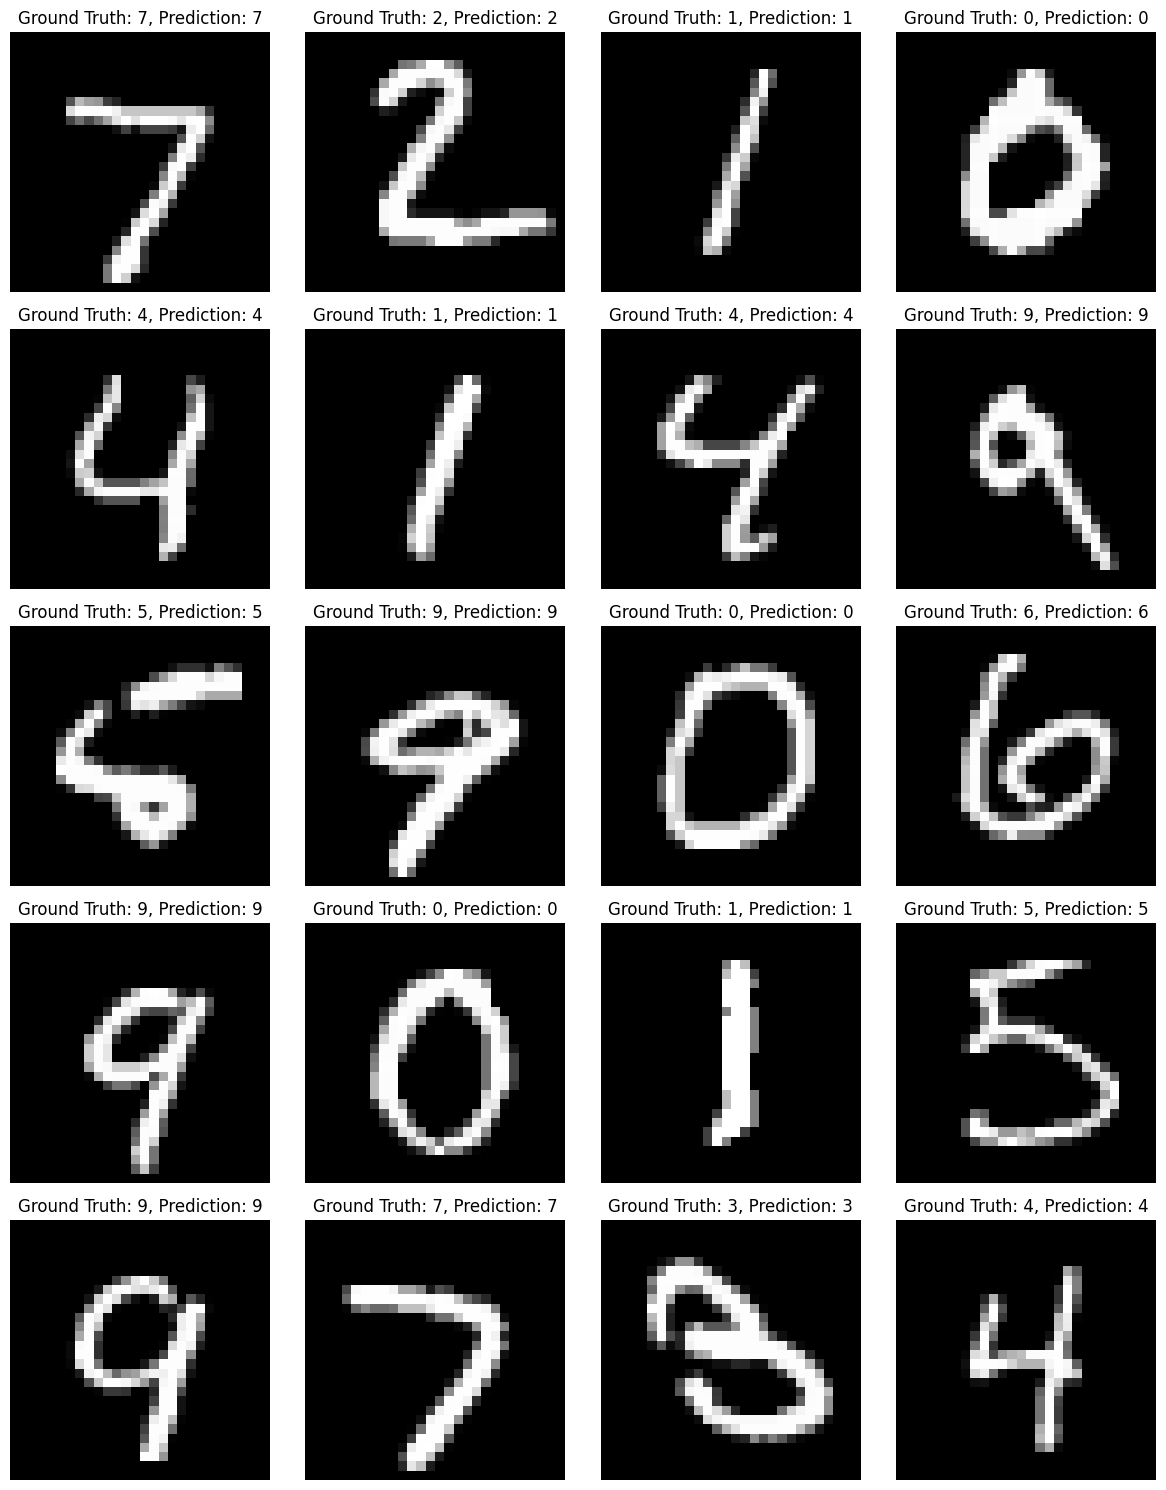


Inference with CNN...


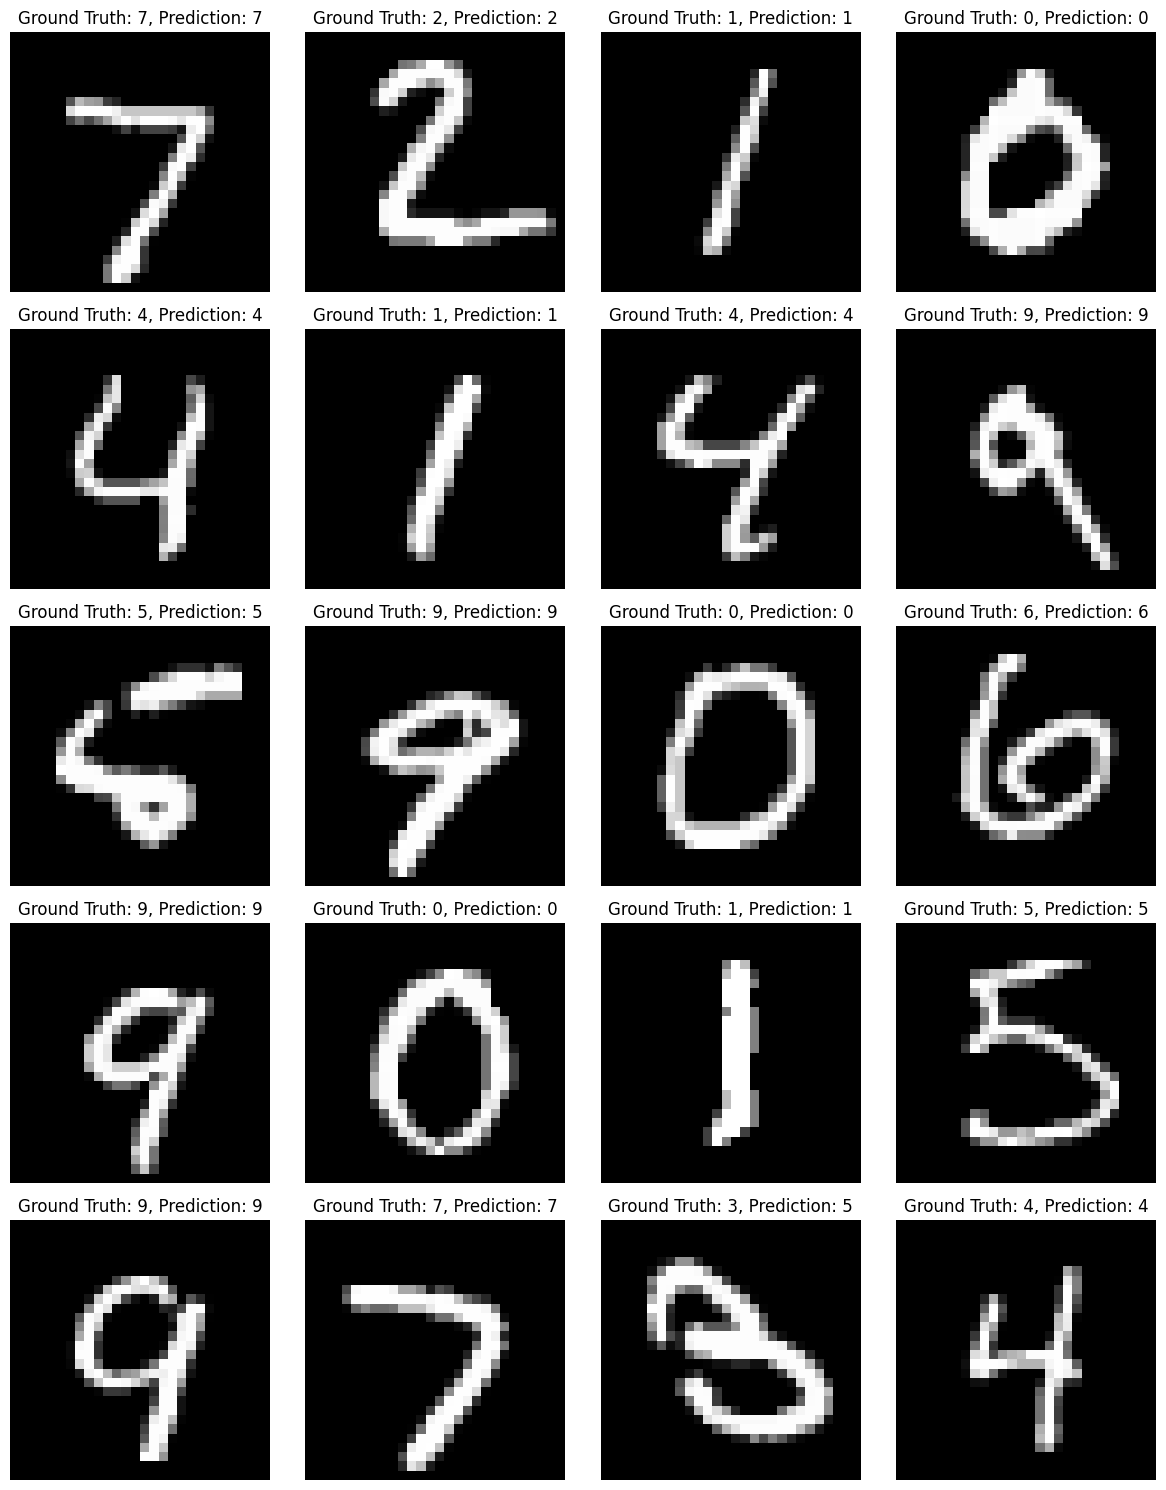


Inference with ResNet...


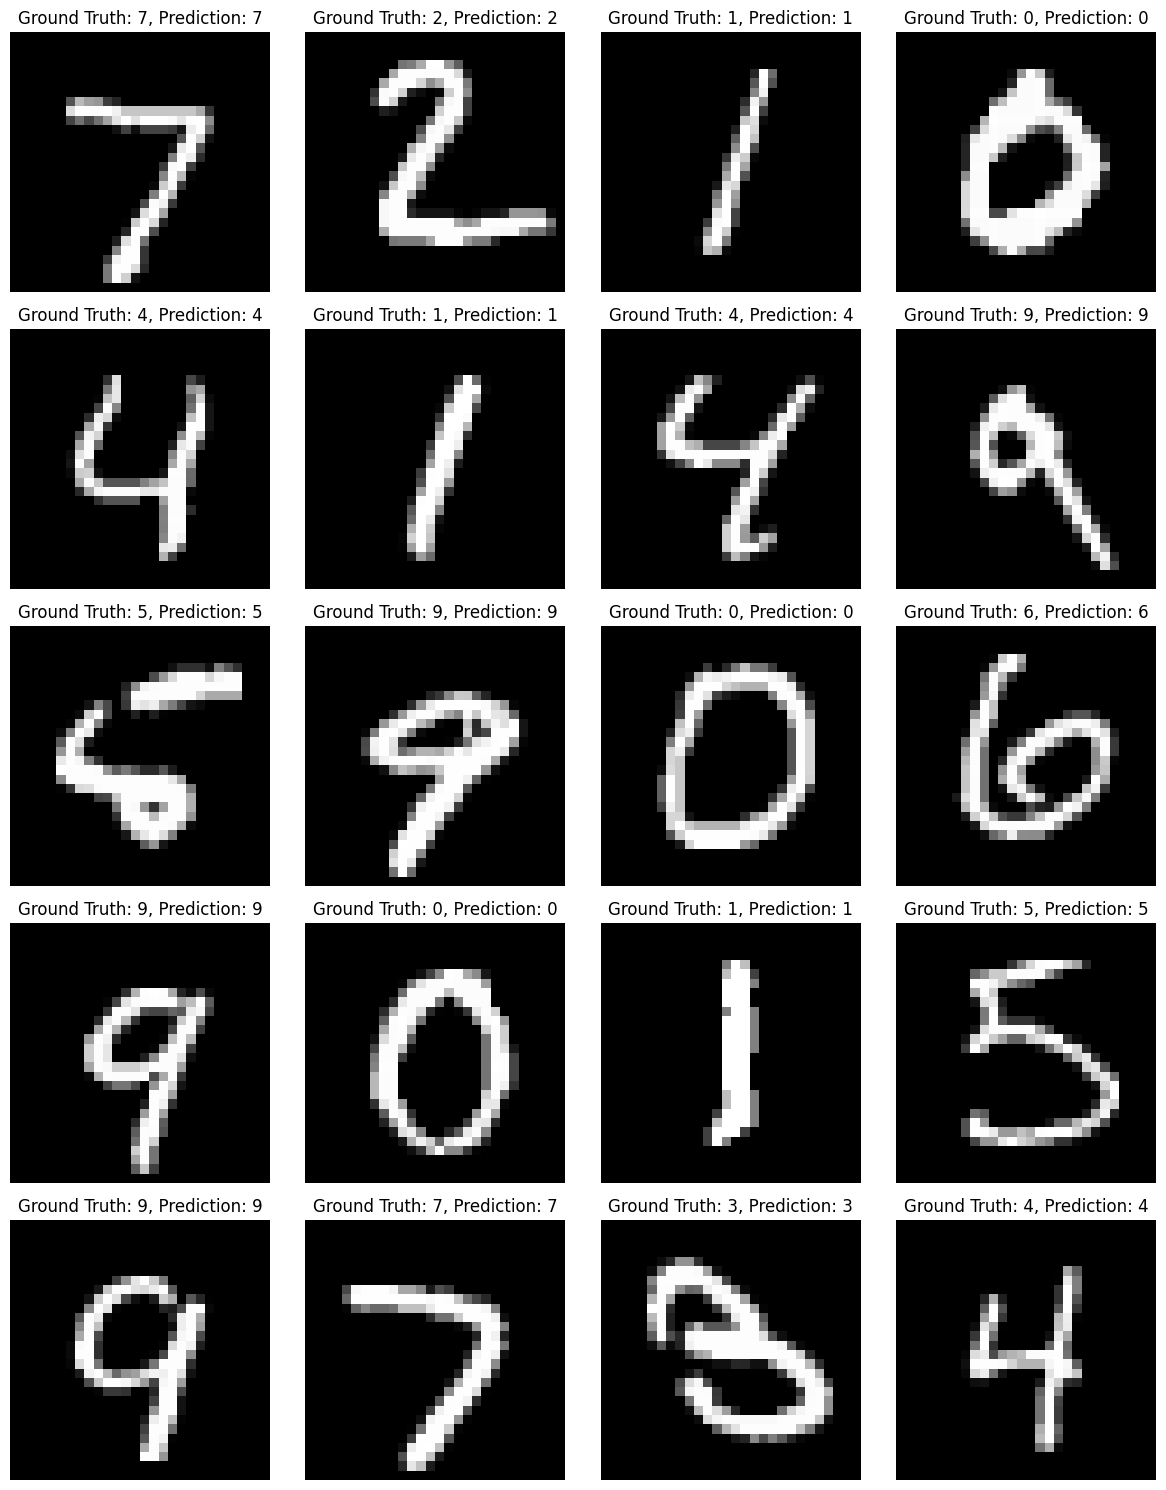

In [118]:
for model_name, model in models.items():
    print(f'\nInference with {model_name}...')
    model.load_state_dict(torch.load(os.path.join(saved_path, f'{model_name}_best.pth')))
    inference(model, test_loader, n_images=20)